# Inspect one ICCL sequence end-to-end

Builds a single sequence from the pilot config and renders its token stream,
task structure, and ground-truth latents. Change `SEED` / `INDEX` to look at
other sequences from the same deterministic stream.

In [4]:
import numpy as np
from omegaconf import OmegaConf

from iccl.data.dataset import make_family, sequence_config_from, sequence_rng
from iccl.data.sequences import TOKEN_BOUNDARY, TOKEN_X, TOKEN_Y, build_sequence

SEED, INDEX = 0, 0

cfg = OmegaConf.load("../configs/data/hyperteacher.yaml")
family = make_family(cfg)
seq = build_sequence(family, sequence_config_from(cfg), sequence_rng(SEED, INDEX))

print(f"tokens {seq.tokens.shape}, {int(seq.loss_mask.sum())} loss positions")
print(f"demo counts: {seq.info['demo_counts'].tolist()}")
print(f"task supports: {[tuple(np.flatnonzero(lat)) for lat in seq.info['latents']]}")

tokens (520, 16), 256 loss positions
demo counts: [32, 32, 32, 32, 32, 32, 32, 32]
task supports: [(np.int64(2), np.int64(4)), (np.int64(2), np.int64(7)), (np.int64(2), np.int64(6)), (np.int64(1), np.int64(2)), (np.int64(3), np.int64(6)), (np.int64(3), np.int64(5)), (np.int64(1), np.int64(5)), (np.int64(0), np.int64(3))]


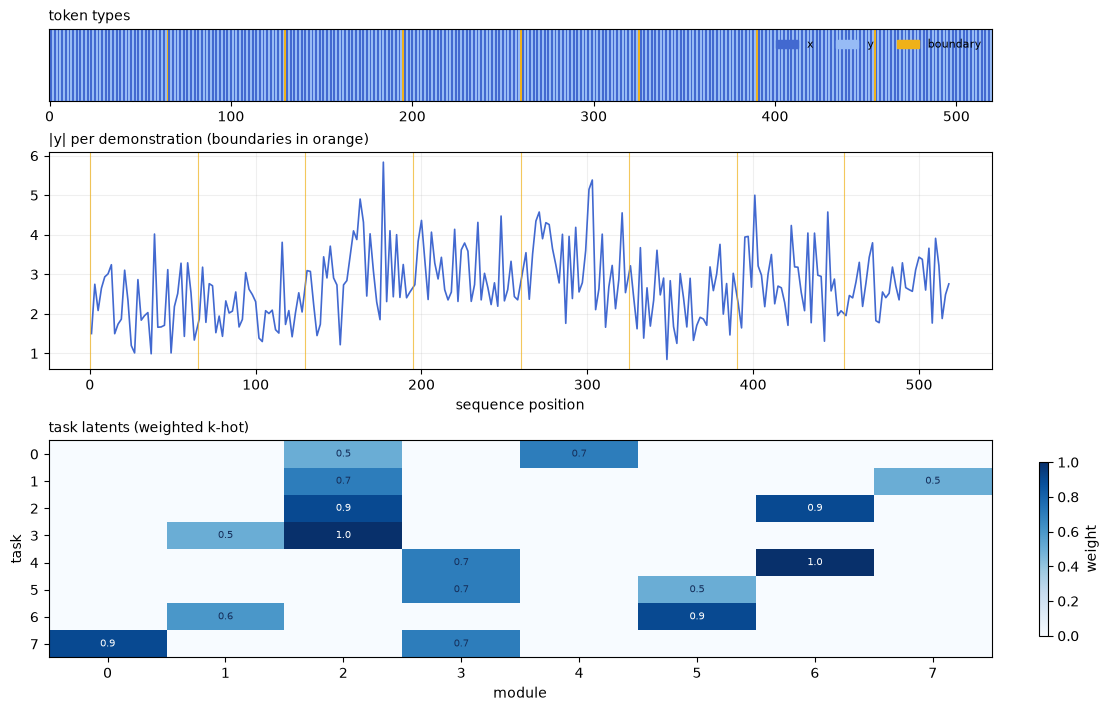

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

TYPE_COLORS = {TOKEN_X: "#4269d0", TOKEN_Y: "#97bbf5", TOKEN_BOUNDARY: "#efb118"}

fig, (ax_strip, ax_norm, ax_lat) = plt.subplots(
    3, 1, figsize=(11, 7), height_ratios=[1, 3, 3], constrained_layout=True
)

# Token-type strip: one row per position, categorical colors, boundaries visible.
cmap = ListedColormap([TYPE_COLORS[t] for t in (TOKEN_X, TOKEN_Y, TOKEN_BOUNDARY)])
ax_strip.imshow(seq.token_type[None, :], aspect="auto", cmap=cmap, interpolation="nearest")
ax_strip.set_yticks([])
ax_strip.set_title("token types", loc="left", fontsize=10)
ax_strip.legend(
    handles=[Patch(color=c, label=n) for n, c in
             [("x", TYPE_COLORS[TOKEN_X]), ("y", TYPE_COLORS[TOKEN_Y]),
              ("boundary", TYPE_COLORS[TOKEN_BOUNDARY])]],
    loc="upper right", ncol=3, frameon=False, fontsize=8,
)

# Target magnitude at each demonstration, task boundaries marked.
x_positions = np.flatnonzero(seq.loss_mask)
norms = np.linalg.norm(seq.targets[x_positions], axis=1)
ax_norm.plot(x_positions, norms, color="#4269d0", linewidth=1.2)
for b in seq.info["boundaries"]:
    ax_norm.axvline(b, color="#efb118", linewidth=0.8, alpha=0.7)
ax_norm.set_title("|y| per demonstration (boundaries in orange)", loc="left", fontsize=10)
ax_norm.set_xlabel("sequence position")
ax_norm.grid(alpha=0.2)

# Ground-truth latents: tasks x modules, single-hue sequential for weight.
lat = seq.info["latents"]
im = ax_lat.imshow(lat, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax_lat.set_xlabel("module")
ax_lat.set_ylabel("task")
ax_lat.set_title("task latents (weighted k-hot)", loc="left", fontsize=10)
ax_lat.set_xticks(range(lat.shape[1]))
ax_lat.set_yticks(range(lat.shape[0]))
for (i, j), w in np.ndenumerate(lat):
    if w > 0:
        ax_lat.text(j, i, f"{w:.1f}", ha="center", va="center", fontsize=7,
                    color="white" if w > 0.7 else "#16305c")
fig.colorbar(im, ax=ax_lat, shrink=0.8, label="weight")
plt.show()

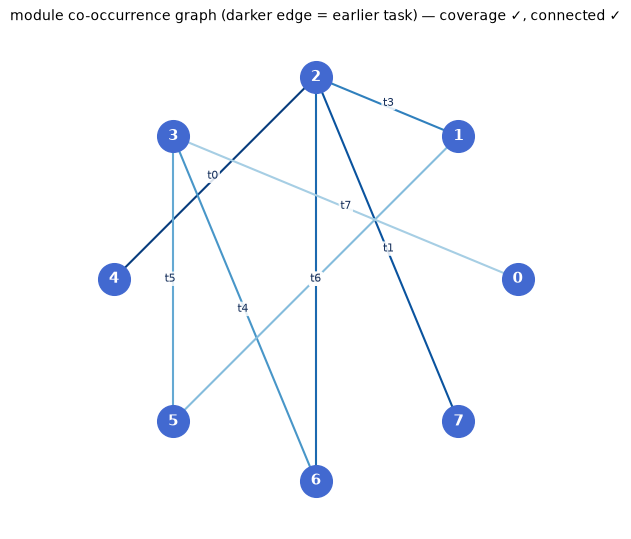

In [6]:
from itertools import combinations

from iccl.data.sequences import check_compositional, check_connected

# Module co-occurrence graph: nodes are modules, an edge appears where two
# modules share a task (k>2 tasks are clique-expanded into pairwise edges).
# Edge color encodes when the edge first appears in the episode; labels name
# the tasks that carry it. This is the structure the identifiability checks
# act on: coverage = every node touched, connected = one component.
supports = [tuple(np.flatnonzero(lat)) for lat in seq.info["latents"]]
num_modules = family.cfg.num_modules
num_tasks = len(supports)
angles = 2 * np.pi * np.arange(num_modules) / num_modules
pos = np.stack([np.cos(angles), np.sin(angles)], axis=1)

edges: dict[tuple[int, int], list[int]] = {}
for t, support in enumerate(supports):
    for a, b in combinations(sorted(support), 2):
        edges.setdefault((a, b), []).append(t)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
cmap = plt.get_cmap("Blues")
for (a, b), tasks in edges.items():
    color = cmap(0.35 + 0.6 * (1 - min(tasks) / max(num_tasks - 1, 1)))
    ax.plot(*pos[[a, b]].T, color=color, linewidth=1.5 + 0.8 * (len(tasks) - 1), zorder=1)
    mid = pos[[a, b]].mean(axis=0) * 1.02
    ax.annotate(",".join(f"t{t}" for t in tasks), mid, fontsize=8,
                ha="center", va="center", color="#16305c",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
ax.scatter(*pos.T, s=520, color="#4269d0", zorder=2)
for m in range(num_modules):
    ax.annotate(str(m), pos[m], ha="center", va="center", color="white",
                fontsize=11, weight="bold", zorder=3)

binary = seq.info["latents"] > 0
coverage = "✓" if check_compositional(binary, num_modules) else "✗"
connected = "✓" if check_connected(binary) else "✗"
ax.set_title(
    f"module co-occurrence graph (darker edge = earlier task) — "
    f"coverage {coverage}, connected {connected}",
    fontsize=10,
)
ax.set_aspect("equal")
ax.margins(0.12)
ax.axis("off")
plt.show()